## MODELOS LINEALES
Los siguientes son un conjunto de métodos destinados a la regresión en el que Se espera que el valor objetivo sea una combinación lineal de las características. En la notación matemática, si Es lo previsto Valor

#### ŷ = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ

Donde:

    ŷ = valor predicho

    w₀ = intercepto (intercept_)

    w₁, w₂, ..., wₙ = coeficientes (coef_)

    x₁, x₂, ..., xₙ = características

### 1.1.1. Plazas mínimos ordinarias

LinearRegression Se ajusta a un modelo lineal con coeficientes. Para minimizar la suma residual de cuadrados entre los objetivos observados en el conjunto de datos, y el Objetivos predichos por la aproximación lineal. Matemáticamente Resuelve un problema de la forma:

![alt text](image-1.png)

In [7]:
#Importar el modulo 
from sklearn import linear_model

# Crear una instancia del modelo de regresion lineal
reg = linear_model.LinearRegression()

# Preparar datos de entrenamiento
# X-> Caracteristicas 
# Y-> Valores objetivo

X = [[0,0],[1,1],[2,2]]
y = [0,1,2]

#Entrenar el modelo 
reg.fit(X,y)

#Examinar el modelo ç
print("Coeficientes:", reg.coef_)
print("Intercepto", reg.intercept_)


Coeficientes: [0.5 0.5]
Intercepto 1.1102230246251565e-16


Muestra 1: [0, 0] → y = 0
Muestra 2: [1, 1] → y = 1  
Muestra 3: [2, 2] → y = 2

El modelo encuentra: ŷ = 0.5*x₁ + 0.5*x₂ + 0

    Para [0, 0]: 0.5*0 + 0.5*0 + 0 = 0 ✓

    Para [1, 1]: 0.5*1 + 0.5*1 + 0 = 1 ✓

    Para [2, 2]: 0.5*2 + 0.5*2 + 0 = 2 ✓

### Ejemplo 1: Prediccion de precios de viviendas


In [36]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Simular datos de casas
np.random.seed(42)
metros_cuadrados = np.random.randint(50, 200, 100)  # 50-200 m²
habitaciones = np.random.randint(1, 5, 100)         # 1-4 habitaciones

# Precio = 1000*metros + 50000*habitaciones + ruido
precio = 1000 * metros_cuadrados + 50000 * habitaciones + np.random.normal(0, 20000, 100)

# Crear matriz de características
X = np.column_stack([metros_cuadrados, habitaciones])

# Entrenar modelo
modelo = LinearRegression()
modelo.fit(X, precio)

print(f"Ecuación: Precio = {modelo.coef_[0]:.0f}*m² + {modelo.coef_[1]:.0f}*hab + {modelo.intercept_:.0f}")

# Predecir para una nueva casa
casa_nueva = np.array([[120, 3], [150, 4]])  # 120 m², 3 habitaciones
precio_predicho = modelo.predict(casa_nueva)
print(f"\nPredicción para casa de 120m² con 3 habitaciones: ${precio_predicho[0]:,.0f}")
print(f"Predicción para casa de 150m² con 4 habitaciones: ${precio_predicho[1]:,.0f}")

Ecuación: Precio = 1028*m² + 49008*hab + 172

Predicción para casa de 120m² con 3 habitaciones: $270,584
Predicción para casa de 150m² con 4 habitaciones: $350,439


### Ejemplo 2: Análisis de Ventas

In [55]:
from sklearn.model_selection import train_test_split
import pandas as pd
datos_publicidad = np.array([ [230, 37, 69], [44, 39, 23], [17, 45, 9], [151, 41, 58], [180, 10, 58], [8, 48, 50], [57, 32, 55], [120, 19, 11], [196, 47, 51], [72, 36, 6] ])
ventas = np.array([22, 10, 9, 18, 17, 7, 13, 14, 20, 12])
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    datos_publicidad, ventas, test_size=0.3, random_state=42
)

print("Datos de entrenamiento:")
print(X_train)
print(y_train)

print("\nDatos de prueba:")
print(X_test)
print(y_test)

modelo_ventas = LinearRegression()
modelo_ventas.fit(X_train, y_train)

#Evaluar
print(f"Ecuación: Ventas = {modelo_ventas.intercept_:.3f} + {modelo_ventas.coef_[0]:.3f}*TV + {modelo_ventas.coef_[1]:.3f}*Radio + {modelo_ventas.coef_[2]:.3f}*Periódico")

print("Coeficientes (impacto de cada medio):")
print(f"  TV: {modelo_ventas.coef_[0]:.3f}")
print(f"  Radio: {modelo_ventas.coef_[1]:.3f}")
print(f"  Periódico: {modelo_ventas.coef_[2]:.3f}")

print("Es el valor de las ventas sin publicidad:")
print(f"Intercepto: {modelo_ventas.intercept_:.3f}")

# Calcular R² (bondad del ajuste)
print("Es el valor de ventas cuando no se invierte nada en publicidad:")
r2 = modelo_ventas.score(X_test, y_test)
print(f"\nR² en datos de prueba: {r2:.3f}")


y_pred = modelo_ventas.predict(X_test)
comparacion = pd.DataFrame({'Real': y_test, 'Predicho': y_pred})
print(comparacion)


Datos de entrenamiento:
[[230  37  69]
 [120  19  11]
 [ 17  45   9]
 [ 72  36   6]
 [180  10  58]
 [151  41  58]
 [ 57  32  55]]
[22 14  9 12 17 18 13]

Datos de prueba:
[[196  47  51]
 [ 44  39  23]
 [  8  48  50]]
[20 10  7]
Ecuación: Ventas = 6.022 + 0.050*TV + 0.055*Radio + 0.034*Periódico
Coeficientes (impacto de cada medio):
  TV: 0.050
  Radio: 0.055
  Periódico: 0.034
Es el valor de las ventas sin publicidad:
Intercepto: 6.022
Es el valor de ventas cuando no se invierte nada en publicidad:

R² en datos de prueba: 0.832
   Real   Predicho
0    20  20.227077
1    10  11.173460
2     7  10.764017


🧠 Resumen ultra simple
Resultado	Qué significa
coef_[0]	impacto TV
coef_[1]	impacto radio
coef_[2]	impacto periódico
intercept_	ventas sin publicidad
R²	qué tan bueno es el modelo
X_test	examen del modelo

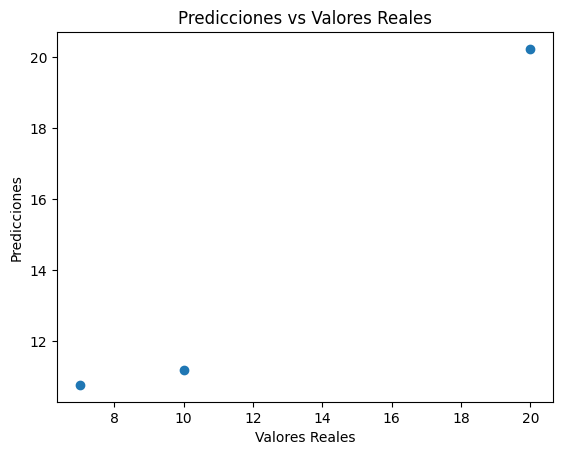

In [56]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales")
plt.show()


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

MAE: 1.7215179577957755
MSE: 5.198797696584517
RMSE: 2.2800872124952845
